In [349]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import itertools
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import seaborn as sns

In [350]:
data = pd.read_excel('DATA.xlsx')
data

,id,sex,q1,q2,q3,q4,q5
0,1,남,0,2,0,70,통학
1,2,여,3,2,0,15,자취
2,3,남,0,0,0,300,통학
3,4,남,0,2,0,160,통학
4,5,남,1,2,0,200,통학
...,...,...,...,...,...,...,...
195,196,남성,1,2,2,60,통학
196,197,여성,0,0,4,50,통학
197,198,여성,2,1,2,60,통학
198,199,남성,2,3,2,90,통학


In [351]:
data['sex'] = data['sex'].replace('남', '1')
data['sex'] = data['sex'].replace('남 ', '1')
data['sex'] = data['sex'].replace('남자', '1')
data['sex'] = data['sex'].replace('남성', '1')
data['sex'] = data['sex'].replace('여', '2')
data['sex'] = data['sex'].replace('여성', '2')
data['sex'] = data['sex'].replace('여성 ', '2')
data['sex'] = data['sex'].astype(int)
data['sex'].unique()

array([1, 2])

In [352]:
data['q5'] = data['q5'].replace('기숙사', '1')
data['q5'] = data['q5'].replace('자취', '2')
data['q5'] = data['q5'].replace('통학', '3')
data['q5'] = data['q5'].astype(int)
data['q5'].unique()

array([3, 2])

C:\Users\compro\AppData\Local\Temp\ipykernel_980\3957529602.py:14: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  plt.tight_layout()
C:\Users\compro\AppData\Local\Temp\ipykernel_980\3957529602.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  plt.tight_layout()
C:\Users\compro\AppData\Local\Temp\ipykernel_980\3957529602.py:14: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from current font.
  plt.tight_layout()
C:\Users\compro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\compro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\compro\AppData\Roaming\Python\Python312\site-packages\IPyth

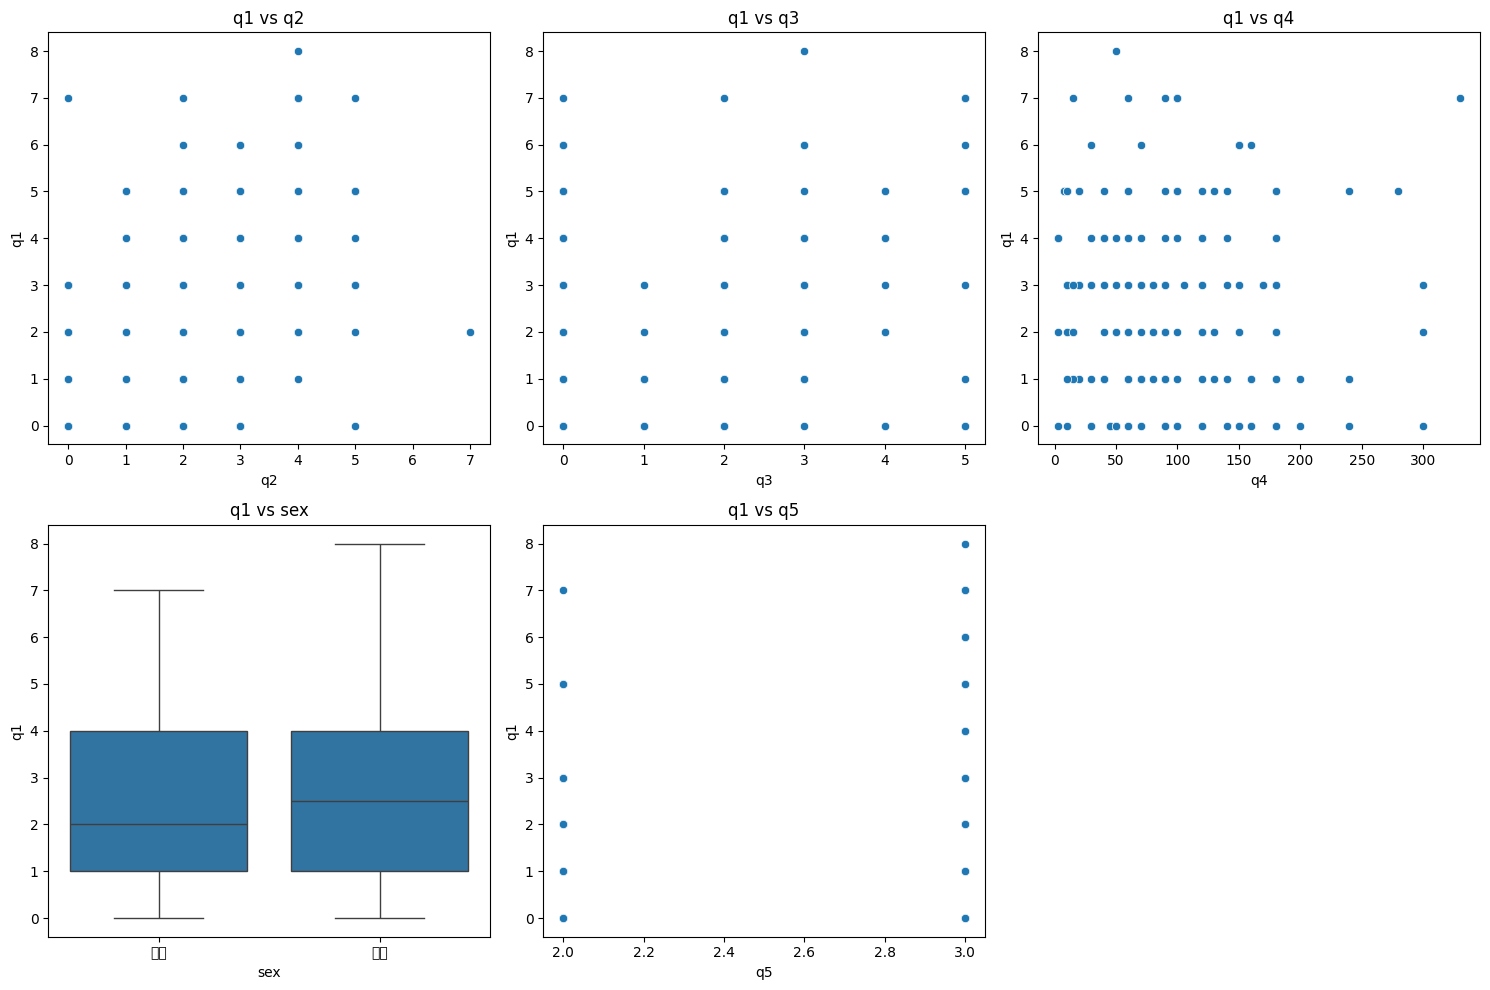

In [ ]:
# 카페이용빈도와 각 변수들의 산점도
data['sex'].replace({1: '남성', 2: '여성'}, inplace=True)

variables = ['q2', 'q3', 'q4', 'sex', 'q5']

plt.figure(figsize=(15, 10))
for i, var in enumerate(variables, 1):
    plt.subplot(2, 3, i)
    if data[var].dtype == 'object':
        sns.boxplot(x=var, y='q1', data=data)
    else:
        sns.scatterplot(x=var, y='q1', data=data)
    plt.title(f'q1 vs {var}')
plt.tight_layout()
plt.show()

In [354]:
data['sex'] = data['sex'].replace('남성', '1')
data['sex'] = data['sex'].replace('여성', '2')
data['sex'] = data['sex'].astype(int)

In [355]:
#이상치 식별
df = pd.DataFrame(data)
df['diffits'] = df['q1'].diff()
df['abs_diffits'] = df['diffits'].abs()

Q1 = df['abs_diffits'].quantile(0.25)
Q3 = df['abs_diffits'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['abs_diffits'] < lower_bound) | (df['abs_diffits'] > upper_bound)]

print("이상치 데이터:")
print(outliers)

이상치 데이터:
      id  sex  q1  q2  q3  q4  q5  diffits  abs_diffits
119  120    2   7   4   5  15   2      7.0          7.0


In [356]:
male_q1 = data[data['sex'] ==1]['q1']
female_q1 = data[data['sex'] ==2]['q1']

In [357]:
print("남성 그룹 q1 값:", male_q1.describe())
print("여성 그룹 q1 값:", female_q1.describe())

남성 그룹 q1 값: count    100.000000
mean       2.470000
std        1.951198
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        7.000000
Name: q1, dtype: float64
여성 그룹 q1 값: count    100.000000
mean       2.520000
std        1.855813
min        0.000000
25%        1.000000
50%        2.500000
75%        4.000000
max        8.000000
Name: q1, dtype: float64


In [358]:
model = smf.ols('q1 ~ q2 * sex', data=data).fit()

In [359]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     12.78
Date:                Sat, 16 Nov 2024   Prob (F-statistic):           1.16e-07
Time:                        18:42:10   Log-Likelihood:                -393.74
No. Observations:                 200   AIC:                             795.5
Df Residuals:                     196   BIC:                             808.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6870      0.732      2.305      0.0

In [360]:
data

,id,sex,q1,q2,q3,q4,q5
0,1,1,0,2,0,70,3
1,2,2,3,2,0,15,2
2,3,1,0,0,0,300,3
3,4,1,0,2,0,160,3
4,5,1,1,2,0,200,3
...,...,...,...,...,...,...,...
195,196,1,1,2,2,60,3
196,197,2,0,0,4,50,3
197,198,2,2,1,2,60,3
198,199,1,2,3,2,90,3


In [361]:
df = pd.DataFrame(data)

In [362]:
y = df['q1']
X = df.drop(columns=['q1', 'id', 'sex','q5'])

In [363]:
def get_all_combinations(features):
    combinations = []
    for r in range(1, len(features) + 1):
        combinations.extend(itertools.combinations(features, r))
    return combinations

In [364]:
feature_columns = X.columns
combinations = get_all_combinations(feature_columns)

In [365]:
results = []

In [366]:
for comb in combinations:
    X_comb = sm.add_constant(X[list(comb)])
    model = sm.OLS(y, X_comb).fit()
    results.append({
        'Variables': comb,
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'AIC': model.aic,
        'BIC': model.bic
    })

In [367]:
results_df = pd.DataFrame(results)

In [368]:
print(results_df.sort_values(by='R-squared', ascending=False))

      Variables  R-squared  Adj. R-squared         AIC         BIC
6  (q2, q3, q4)   0.230508        0.218730  778.799478  791.992747
3      (q2, q3)   0.228345        0.220511  777.360822  787.255774
4      (q2, q4)   0.162070        0.153563  793.840322  803.735275
0         (q2,)   0.162050        0.157818  791.845006  798.441641
5      (q3, q4)   0.112597        0.103588  805.313139  815.208091
1         (q3,)   0.110246        0.105752  803.842506  810.439141
2         (q4,)   0.000320       -0.004729  827.140524  833.737159


In [369]:
X = df[['q2', 'q3']]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Variable       VIF
0    const  3.878146
1       q2  1.040738
2       q3  1.040738


In [370]:
X = df[['q2', 'q3']]
y = df['q1']
X = sm.OLS(y,X).fit()
print(model.summary())
params = model.params
print(f"회귀식: y = {params['const']} + {params['q2']}*q2 + {params['q3']}*q3")

                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     19.57
Date:                Sat, 16 Nov 2024   Prob (F-statistic):           3.86e-11
Time:                        18:42:10   Log-Likelihood:                -385.40
No. Observations:                 200   AIC:                             778.8
Df Residuals:                     196   BIC:                             792.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8527      0.307      2.780      0.0

In [371]:
correlation_matrix = data[['q1', 'q2', 'q3', 'q4', 'q5']].corr()
print(correlation_matrix)

          q1        q2        q3        q4        q5
q1  1.000000  0.402555  0.332032 -0.017878 -0.015245
q2  0.402555  1.000000  0.197846 -0.033414 -0.071657
q3  0.332032  0.197846  1.000000 -0.197041 -0.065851
q4 -0.017878 -0.033414 -0.197041  1.000000  0.474566
q5 -0.015245 -0.071657 -0.065851  0.474566  1.000000


In [372]:
X = df[['q2', 'q3']]
y = df['q1']

In [373]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [374]:
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['q2', 'q3']))

In [375]:
model = LinearRegression()
model.fit(X_poly, y)

LinearRegression()

In [376]:
intercept = model.intercept_
coefs = model.coef_

In [377]:
print("회귀식:")
terms = " + ".join([f"({coefs[i]})*{name}" for i, name in enumerate(X_poly_df.columns)])
print(f"y = {intercept} + {terms}")

회귀식:
y = 0.999121358306134 + (0.6057343811085005)*q2 + (0.14860585092162798)*q3 + (-0.04311098245296709)*q2^2 + (0.04323345806651397)*q2 q3 + (0.016956429675773727)*q3^2


In [378]:
y_pred = model.predict(X_poly)
mse = np.mean((y - y_pred) ** 2)
r2 = model.score(X_poly, y)

In [379]:
print(f"\nMean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 2.749858324680439
R-squared: 0.23401741664484055


In [380]:
X_poly_df = sm.add_constant(X_poly_df)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_poly_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_poly_df.values, i) for i in range(X_poly_df.shape[1])]

In [381]:
print("\nVIF 값:")
print(vif_data)


VIF 값:
  Variable       VIF
0    const  7.970335
1       q2  8.400254
2       q3  9.016153
3     q2^2  9.161943
4    q2 q3  6.918905
5     q3^2  8.915014


In [390]:
q5_dummies = pd.get_dummies(data['q5'], prefix='q5', drop_first=True)
data = pd.concat([data, q5_dummies], axis=1)
data['q5_3'] = data['q5_3'].astype(int)
X = data[['q2', 'q3', 'q5_3']]
y = data['q1']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     q1   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     19.41
Date:                Sat, 16 Nov 2024   Prob (F-statistic):           4.61e-11
Time:                        18:47:26   Log-Likelihood:                -385.58
No. Observations:                 200   AIC:                             779.2
Df Residuals:                     196   BIC:                             792.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8779      0.366      2.402      0.0

Index(['q5_3'], dtype='object')
q2      int64
q3      int64
q5_3     bool
q5_3     bool
q5_3     bool
dtype: object
